### What are we doing here?

In this step, we are finding real LIGO data around a known gravitational-wave event called `GW151226`.

First, we choose the event we want to study. Using the `event_gps()` function, we get the exact time when this event happened. LIGO uses GPS time, so the time appears as a large number of seconds instead of a normal calendar date.

Next, we define a data window of `4096` seconds. We do not take only the exact moment of the event. Instead, we take a larger time interval around it, with the event placed roughly in the middle. This gives us data from before and after the event.

Then, we use `get_urls()` to find which GWOSC files contain the data for this time interval. We ask for data from the `H1` detector, which is LIGO Hanford, and we request a sample rate of `16384 Hz`.

The sample rate tells us how many measurements we have per second. So at `16384 Hz`, every second contains `16384` strain values.

Finally, we print how many files were found and display their links. At this point, we have not downloaded the data yet. We have only found the files that we need to download.

In [44]:
from gwosc.datasets import event_gps  # Import the function that returns the GPS time of a gravitational-wave event
from gwosc.locate import get_urls  # Import the function that finds data file URLs from GWOSC


event = "GW151226"  # Name of the gravitational-wave event we want to analyze
gps = event_gps(event)  # Get the official GPS time of this event

print(f"{event}: {gps}")  # Print the event name and its GPS time


duration = 4096  # Total length of data to request, in seconds
half_duration = duration // 2  # Half of the total duration, used to center the time window on the event

start = int(gps - half_duration)  # Start GPS time: half the duration before the event
end = int(gps + half_duration)  # End GPS time: half the duration after the event

print(f"Start: {start}")
print(f"End: {end}")
print(f"Duration: {end - start}")


urls = get_urls(  # Find the GWOSC data files that match the requested detector, time range, and sample rate
    detector="H1",  # Use the Hanford detector data
    start=start,  # Start of the requested data window
    end=end,  # End of the requested data window
    sample_rate=16384,  # Request data sampled at 16384 samples per second
)

print(f"Number of files: {len(urls)}")

for url in urls:  # Loop through each data file URL
    print(url)  # Print the URL so we can download or inspect the file later

GW151226: 1135136350.6
Start: 1135134302
End: 1135138398
Duration: 4096
Number of files: 2
https://gwosc.org/archive/data/O1_16KHZ/1134559232/H-H1_LOSC_16_V1-1135132672-4096.hdf5
https://gwosc.org/archive/data/O1_16KHZ/1134559232/H-H1_LOSC_16_V1-1135136768-4096.hdf5


In this step, we download one of the LIGO data files that we found in the previous step.

First, we import a few tools. `requests` is used to download files from the internet. `Path` helps us create and manage folders/files in a clean way. `tqdm` gives us a progress bar so we can see the download progress.

Then, we create a folder called `data`. This is where we will store the downloaded LIGO file. If the folder already exists, Python will not create it again and will not give an error.

Next, we choose the first URL from the list of files using `urls[0]`. This is the file we want to download first. We also create a local filename using the original filename from the URL, so the file keeps a meaningful name.

After that, we send a request to the URL and start downloading the file in small pieces instead of loading everything into memory at once. This is useful because LIGO data files can be quite large.

The `raise_for_status()` line checks if the download request worked correctly. If something went wrong, it will stop the code and show an error.

Then, we open a new file in write-binary mode (`"wb"`) and save each downloaded chunk into it. The progress bar updates as each chunk is written.

At the end, we print a message showing that the download is finished and where the file was saved.

In [46]:
import requests  # Import requests to download files from the internet
from pathlib import Path  # Import Path to work with folders and file paths cleanly
from tqdm import tqdm  # Import tqdm to show a download progress bar


data_dir = Path("data")  # Create a Path object for the folder where the data will be saved
data_dir.mkdir(exist_ok=True)  # Create the folder if it does not already exist

url = urls[0]  # Select the first data file URL from the list of URLs
filename = data_dir / url.split("/")[-1]  # Create the local filename using the last part of the URL

print("Downloading:")
print("To:", filename)

response = requests.get(url, stream=True)  # Start downloading the file as a stream, without loading it all into memory
response.raise_for_status()  # Stop the program if the download request failed

total_size = int(response.headers.get("content-length", 0))  # Get the total file size in bytes, or 0 if it is unknown

with open(filename, "wb") as file:  # Open the output file in binary write mode
    with tqdm(total=total_size, unit="B", unit_scale=True) as progress_bar:  # Create a progress bar measured in bytes
        for chunk in response.iter_content(chunk_size=8192):  # Download the file in small chunks of 8192 bytes
            if chunk:  # Make sure the chunk is not empty
                file.write(chunk)  # Write the chunk to the local file
                progress_bar.update(len(chunk))  # Update the progress bar by the number of bytes downloaded

print("Done:", filename)

Downloading:
To: data\H-H1_LOSC_16_V1-1135132672-4096.hdf5


100%|██████████| 71.2M/71.2M [01:25<00:00, 831kB/s] 

Done: data\H-H1_LOSC_16_V1-1135132672-4096.hdf5


In this step, we open the downloaded LIGO data file and read the strain data from it.

The file is in `.hdf5` format, which is commonly used for storing large scientific datasets. We use `h5py` to open the file in read mode and access the dataset that contains the detector measurements.

Inside the file, the strain data is stored in the `strain` group, under the dataset named `Strain`. To make the code cleaner, we first store this dataset in a variable called `strain_dataset`.

We also print the top-level keys of the file and the keys inside the `strain` group. This helps us inspect the structure of the HDF5 file and confirm where the data is stored.

Next, we load the full strain time series into a NumPy array. This array contains the actual strain measurements recorded by the H1 LIGO detector.

We also read two important metadata values from the dataset attributes:

- `Xspacing`: the time difference between two consecutive samples
- `Xstart`: the GPS time at which the data file begins

Using `Xspacing`, we calculate the sample rate. Then, we calculate the total duration of the data and the GPS end time.

Finally, we print some basic information about the data:

- the number of samples
- the sample rate
- the GPS start time
- the GPS end time
- the total duration of the data

This helps us confirm that the file was read correctly and that it contains the expected amount of data.

In [47]:
import h5py  # Import h5py to read HDF5 scientific data files
import numpy as np  # Import NumPy for numerical calculations and array handling


with h5py.File(filename, "r") as file:  # Open the downloaded HDF5 file in read-only mode
    strain_dataset = file["strain"]["Strain"]  # Access the dataset that contains the detector strain time series

    print("Top-level keys:", list(file.keys()))  # Print the main groups stored inside the HDF5 file
    print("Strain keys:", list(file["strain"].keys()))  # Print the datasets stored inside the strain group

    strain = strain_dataset[:]  # Load the full strain time series into a NumPy array
    dt = strain_dataset.attrs["Xspacing"]  # Read the time spacing between two consecutive samples, in seconds
    gps_start = strain_dataset.attrs["Xstart"]  # Read the GPS start time of the data file


sample_rate = int(round(1 / dt))  # Calculate the sample rate from the time spacing
duration = len(strain) / sample_rate  # Calculate the total duration of the data, in seconds
gps_end = gps_start + duration  # Calculate the GPS end time of the data file

print(f"Samples: {len(strain)}")
print(f"Sample rate: {sample_rate}")
print(f"GPS start: {gps_start}")
print(f"GPS end: {gps_end}")
print(f"Duration: {duration} seconds")

Top-level keys: ['meta', 'quality', 'strain']
Strain keys: ['Strain']
Samples: 67108864
Sample rate: 16384
GPS start: 1135132672
GPS end: 1135136768.0
Duration: 4096.0 seconds


In this step, we find where the event is located inside the downloaded LIGO data file.

The variable `gps` is the GPS time of the event `GW151226`.

The variable `gps_start` is the GPS time where the data file starts.

By subtracting them:

```python
event_offset = gps - gps_start

In [48]:
event_offset = gps - gps_start  # Calculate how many seconds after the file start the event occurs

event_index = int(event_offset * sample_rate)  # Convert the event time offset from seconds to a sample index

print("Event offset from file start:", event_offset, "seconds")
print("Event sample index:", event_index)

Event offset from file start: 3678.5999999046326 seconds
Event sample index: 60270182


In this step, we plot a small 8-second window of raw LIGO strain data around the event `GW151226`.

First, we find the position of the event inside the strain array by converting the event time from seconds into a sample index.

Then, we choose an 8-second window centered on the event. This means we take 4 seconds before the event and 4 seconds after the event.

We extract that part of the strain array and create a time axis where `0` seconds corresponds to the event time.

The final plot shows the raw strain measured by the H1 detector around `GW151226`.

At this stage, the data is still raw, so the plot mostly shows detector noise.

Event offset: 3678.5999999046326
Event index: 60270182


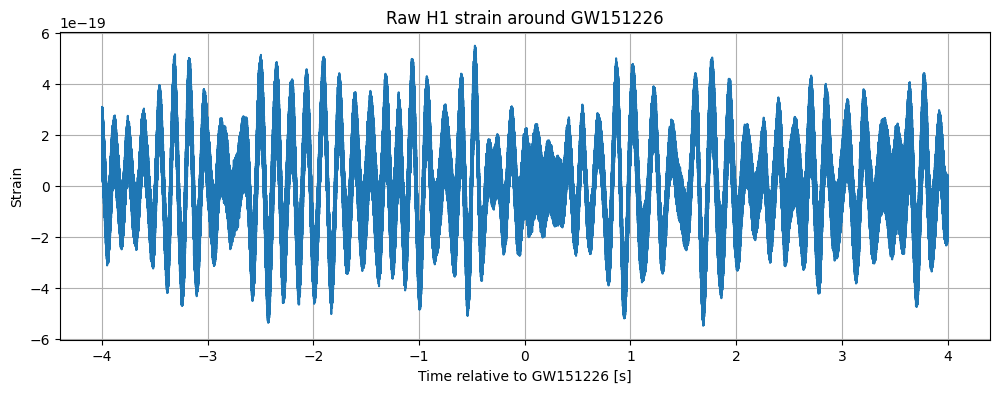

In [49]:
import matplotlib.pyplot as plt  # Import Matplotlib for plotting the strain data
import numpy as np  # Import NumPy for creating the time axis


event_offset = gps - gps_start  # Calculate how many seconds after the file start the event occurs
event_index = int(event_offset * sample_rate)  # Convert the event time offset into a sample index

print(f"Event offset: {event_offset}")  # Print the event position in seconds relative to the file start
print(f"Event index: {event_index}")  # Print the event position as an index inside the strain array


seconds_to_plot = 8  # Total length of the plot window, in seconds
half_window = int(seconds_to_plot * sample_rate / 2)  # Half of the plot window, measured in samples

start = event_index - half_window  # Start index of the segment, before the event
end = event_index + half_window  # End index of the segment, after the event

strain_segment = strain[start:end]  # Extract the strain data around the event


time = np.arange(len(strain_segment)) / sample_rate  # Create a time axis in seconds for the extracted segment
time -= seconds_to_plot / 2  # Shift the time axis so that the event is at time zero


plt.figure(figsize=(12, 4))  # Create a figure with a wide layout
plt.plot(time, strain_segment)  # Plot the raw strain data around the event

plt.xlabel("Time relative to GW151226 [s]")
plt.ylabel("Strain")
plt.title("Raw H1 strain around GW151226") 
plt.grid(True)

plt.show()

In this step, we zoom in and plot only `1` second of raw strain data around the event `GW151226`.

We set `seconds_to_plot = 1`, which means that the plot will show a total duration of `1` second.

Then, we calculate `half`, which is the number of samples corresponding to half of this time window. We do this because we want the event to be centered in the plot. So, for a `1` second window, we take `0.5` seconds before the event and `0.5` seconds after the event.

Next, we extract this small part of the full `strain` array. The extracted segment is centered around `event_index`, which is the position of the event inside the strain data.

After that, we create a time axis for the plot. This axis is measured in seconds and is shifted so that `0` corresponds to the event time. Negative values show time before the event, and positive values show time after the event.

Finally, we plot the extracted strain segment. The x-axis shows time relative to `GW151226`, and the y-axis shows the raw strain measured by the H1 detector.

At this stage, the data is still raw, so the plot mostly shows detector noise.

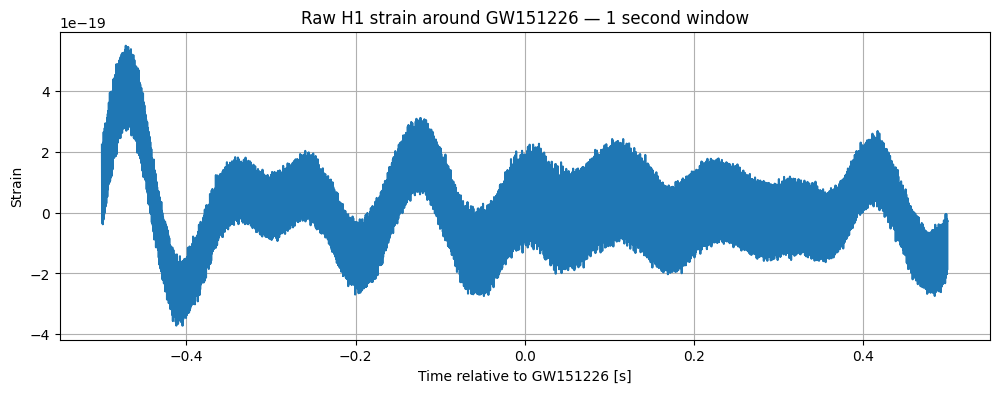

In [50]:
seconds_to_plot = 1  # Total length of the plot window, in seconds
half_window = int(seconds_to_plot * sample_rate / 2)  # Half of the plot window, measured in samples

start = event_index - half_window  # Start index of the segment, before the event
end = event_index + half_window  # End index of the segment, after the event

strain_segment = strain[start:end]  # Extract the strain data around the event

time = np.arange(len(strain_segment)) / sample_rate  # Create a time axis in seconds for the extracted segment
time -= seconds_to_plot / 2  # Shift the time axis so that the event is at time zero

plt.figure(figsize=(12, 4))
plt.plot(time, strain_segment)

plt.xlabel("Time relative to GW151226 [s]")
plt.ylabel("Strain")
plt.title("Raw H1 strain around GW151226 — 1 second window")
plt.grid(True)

plt.show()

In this step, we reduce the sample rate of the strain data.

The original data has a sample rate of `16384 Hz`. This means that every second contains `16384` strain values.

For now, we do not need that many samples per second, so we reduce the sample rate to `8192 Hz`.

This makes the data smaller and easier to process.

We use `resample_poly` to downsample the signal. The line `strain_8192 = resample_poly(strain, up=1, down=2)` creates a new strain array with half the number of samples.

Since the original sample rate is `16384 Hz`, reducing it by a factor of `2` gives us `8192 Hz`.

Because the sample rate changed, the old event index is no longer correct. The event happens at the same physical time, but its position inside the new array is different.

So we calculate a new event index using the event offset and the new sample rate.

Finally, we print the original sample rate, the new sample rate, the original number of samples, the new number of samples, and the new event index.

This helps us check that the downsampling worked correctly.

In [ ]:
from scipy.signal import resample_poly  # Import the function used to change the sample rate of a signal


target_sample_rate = 8192  # Define the sample rate we want after downsampling

strain_8192 = resample_poly(strain, up=1, down=2)  # Downsample the strain data from 16384 Hz to 8192 Hz
fs = target_sample_rate  # Store the new sample rate in a shorter variable name

event_index_8192 = int(event_offset * fs)  # Convert the event time offset to a sample index at the new sample rate

print(f"Original sample rate: {sample_rate}")
print(f"New sample rate: {fs}")
print(f"Original samples: {len(strain)}")
print(f"New samples: {len(strain_8192)}")
print(f"Event index at 8192 Hz: {event_index_8192}")

Original sample rate: 16384
New sample rate: 8192
Original samples: 67108864
New samples: 33554432
Event index at 8192 Hz: 30135091


In this step, we extract a smaller part of the downsampled strain data around `GW151226`.

We already downsampled the full strain array to `8192 Hz`. Now we do not want to process the whole file at once, because the full file contains many `NaN` values.

Instead, we take a short segment centered on the event.

We want to eventually plot `1` second of data, but we also add `2` seconds of padding before and after. This gives the filter extra data to work with.

So the total segment is:

- `1` second for the final plot
- `2` seconds before it
- `2` seconds after it

This gives us `5` seconds of data in total.

We then calculate the start and end indices of this segment using the event index at `8192 Hz`.

Finally, we extract that segment from `strain_8192` and print:

- how many samples it contains
- how many `NaN` values it contains

This helps us check whether the segment is safe to filter.

In [67]:
seconds_to_plot = 1  # Final window we want to plot, in seconds
padding_seconds = 2  # Extra time before and after the plot window for filtering

total_seconds = seconds_to_plot + 2 * padding_seconds  # Total segment length including padding
half_window = int(total_seconds * fs / 2)  # Half of the total segment length, measured in samples

start = event_index_8192 - half_window  # Start index of the segment
end = event_index_8192 + half_window  # End index of the segment

strain_segment_8192 = strain_8192[start:end]  # Extract a small segment around the event

print(f"Segment samples: {len(strain_segment_8192)}")
print(f"NaNs in segment: {np.isnan(strain_segment_8192).sum()}")

Segment samples: 40960
NaNs in segment: 0


In this step, we apply a bandpass filter to the small segment around `GW151226`.

The segment does not contain any `NaN` values, so it is safe to filter.

The raw strain data contains many different frequencies. Some of them are useful for this project, while others are mostly noise.

Here, we keep frequencies between `30 Hz` and `500 Hz`.

This means that very low frequencies and very high frequencies are reduced.

We define a function called `bandpass_filter` so we can reuse the same filtering process later.

Inside the function, we first calculate the Nyquist frequency, which is half of the sample rate.

Then, we convert the lower and upper frequency limits into normalized values. This is needed because the filter function expects frequencies relative to the Nyquist frequency.

Next, we create the bandpass filter using `butter`.

After that, we apply the filter using `filtfilt`. This filters the data without shifting the signal in time.

Finally, we apply the filter to our clean segment and print basic information to check that the filtering worked correctly.

In [68]:
from scipy.signal import butter, filtfilt  # Import tools for creating and applying a filter


def bandpass_filter(data, low_freq, high_freq, fs, order=4):
    nyquist = fs / 2  # Highest frequency we can represent with this sample rate

    low = low_freq / nyquist  # Convert the lower cutoff frequency to normalized form
    high = high_freq / nyquist  # Convert the upper cutoff frequency to normalized form

    b, a = butter(order, [low, high], btype="band")  # Create the bandpass filter
    filtered_data = filtfilt(b, a, data)  # Apply the filter without shifting the signal in time

    return filtered_data


filtered_segment_8192 = bandpass_filter(
    data=strain_segment_8192,
    low_freq=30,
    high_freq=500,
    fs=fs,
)

print("Bandpass filtering done.")
print(f"Filtered segment samples: {len(filtered_segment_8192)}")
print(f"NaNs in filtered segment: {np.isnan(filtered_segment_8192).sum()}")

Bandpass filtering done.
Filtered segment samples: 40960
NaNs in filtered segment: 0


In this step, we plot the filtered strain data around `GW151226`.

In the previous step, we filtered a longer segment that included extra padding. Now we only want to display the central `1` second around the event.

First, we find the center of the filtered segment. Since the segment was centered on the event, the center corresponds to the event time.

Then, we calculate how many samples correspond to half of the final plot window.

Because the final plot is `1` second long, we take:

- `0.5` seconds before the event
- `0.5` seconds after the event

Next, we extract this central part from the filtered segment.

After that, we create a time axis in seconds and shift it so that `0` corresponds to the event time.

Finally, we plot the filtered strain values.

The x-axis shows time relative to `GW151226`.

The y-axis shows the bandpass-filtered strain.

This plot shows the same event region as before, but after reducing frequencies outside the `30 Hz` to `500 Hz` range.

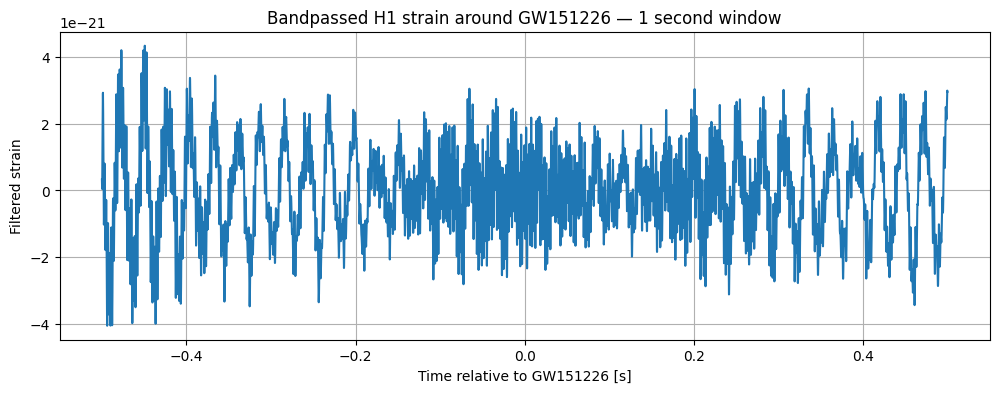

In [69]:
center = len(filtered_segment_8192) // 2  # Center of the filtered segment
half_plot = int(seconds_to_plot * fs / 2)  # Half of the final plot window, measured in samples

start = center - half_plot  # Start index for the final 1-second window
end = center + half_plot  # End index for the final 1-second window

filtered_plot_segment = filtered_segment_8192[start:end]  # Extract the central 1-second filtered segment

time = np.arange(len(filtered_plot_segment)) / fs  # Create a time axis in seconds
time -= seconds_to_plot / 2  # Shift the time axis so that 0 is the event time

plt.figure(figsize=(12, 4))
plt.plot(time, filtered_plot_segment)

plt.xlabel("Time relative to GW151226 [s]")
plt.ylabel("Filtered strain")
plt.title("Bandpassed H1 strain around GW151226 — 1 second window")
plt.grid(True)

plt.show()

In this step, we check the numerical values of the raw and filtered strain data.

The plot shows that the filtered signal is much smaller than the raw signal. This is expected because the bandpass filter removed many frequency components from the original data.

First, we print the minimum and maximum values of the raw segment.

Then, we print the minimum and maximum values of the filtered segment.

This lets us compare the size of the signal before and after filtering.

We also check whether the filtered segment contains any `NaN` values.

If the number of `NaN` values is `0`, then the filtered data is valid and we can continue using it.

In [70]:
print(f"Raw segment min: {np.min(strain_segment)}")
print(f"Raw segment max: {np.max(strain_segment)}")
print(f"Filtered segment min: {np.min(filtered_plot_segment)}")
print(f"Filtered segment max: {np.max(filtered_plot_segment)}")
print(f"NaNs in filtered plot segment: {np.isnan(filtered_plot_segment).sum()}")

Raw segment min: nan
Raw segment max: nan
Filtered segment min: -4.0499376718191604e-21
Filtered segment max: 4.3297690575470896e-21
NaNs in filtered plot segment: 0
